# Data Analysis Mathematics, Algorithms and Modeling

## Team Information - **Problem Analysis Workshop 5**

**Team Members**

Name: Ayush Patel  
Student Number: 9033358

Name: Nikhil Shankar  
Student Number: 9026254

Name: Sreehari Prathap  
Student Number: 8903199


## Step 1: Install and Configure the IDE (e.g., Jupyter Notebook and VS Code)
- Install Anaconda (for Jupyter Notebook) and Visual Studio Code (VS Code).
  - Anaconda: Visit [anaconda.com](https://www.anaconda.com/products/individual) and download the appropriate installer for our operating system.
  - VS Code: Download and install from [Visual Studio Code](https://code.visualstudio.com/).
- Install Pandas Library
  - Open the terminal and run the following command: `pip install pandas`

## Step 2: Downloading the Dataset
We are using the Utrecht Fairness Recruitment dataset from [Kaggle], which can be downloaded directly via the link:
- URL: [https://www.kaggle.com/datasets/ictinstitute/utrecht-fairness-recruitment-dataset]

## Step 3: Differences Between Simple, Linear, Non-Linear, and Logistic Regressions

#### 1. Simple Regression
- **Definition**: A regression model with **one independent variable** and one dependent variable.
- **Type**: Can be linear or non-linear.
- **Example**: Predicting house price based on area.
$$y = \beta_0 + \beta_1x + \epsilon$$

---

#### 2. Linear Regression
- **Definition**: A regression model where the relationship between independent and dependent variables is **linear**.
- **Type**: Includes simple (one independent variable) and multiple (two or more independent variables).
- **Assumptions**:
  - Linearity
  - Homoscedasticity (constant variance of errors)
  - Independence of errors
  - Normally distributed errors
- **Example**: Predicting sales based on advertising spend.
- **Equation**: $$y = \beta_0 + \beta_1x_1 + \beta_2x_2 + \ldots + \epsilon$$

---

#### 3. Non-Linear Regression
- **Definition**: Models where the relationship between variables is **non-linear**, i.e., the dependent variable is modeled as a non-linear function of independent variables.
- **Use Case**: When data cannot be approximated well with a straight line.
- **Equation**: $$y = f(x) + \epsilon$$, where \( f(x) \) is a non-linear function.
- **Example**: Growth models, polynomial regression $$y = ax^2 + bx + c$$

---

#### 4. Logistic Regression
- **Definition**: A type of regression used when the dependent variable is **categorical** (e.g., binary outcomes like "Yes/No" or "0/1").
- **Type**: Not linear in the dependent variable; the logistic function (sigmoid) maps outputs to probabilities.
- **Equation**: 
  $$[ P(y=1|x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1x_1 + \ldots)}}$$
  - **Example**: Predicting whether a customer will purchase a product (1) or not (0).

---

#### Key Differences at a Glance

| Feature                 | Simple Regression     | Linear Regression      | Non-Linear Regression  | Logistic Regression     |
|-------------------------|-----------------------|------------------------|------------------------|-------------------------|
| **Independent Variables** | 1                   | 1 or more              | 1 or more              | 1 or more               |
| **Dependent Variable**   | Continuous           | Continuous             | Continuous             | Categorical             |
| **Relationship**         | Linear/Non-linear    | Linear                 | Non-linear             | Non-linear              |
| **Output**               | Numeric values       | Numeric values         | Numeric values         | Probability (0–1)       |
| **Use Case**             | Simple scenarios     | Predict continuous data | Complex patterns       | Classification problems |


## Step 4: Data Analysis

In [52]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from scipy.stats import chi2_contingency
from sklearn.impute import SimpleImputer
import warnings

warnings.filterwarnings("ignore", category=UserWarning) 

# Define a class for the analysis
class GenderBiasAnalysis:
    
    def __init__(self, dataset_path):
        self.data = pd.read_csv(dataset_path)
        self.X = None
        self.y = None
        self.model_logistic = None
        self.model_tree = None
        
    # function to print the unique values in a column 
    def unique_values(self, column):
        print(self.data[column].unique())
        
    def preprocess_data(self):
        # Check and print columns with missing values
        print("Missing values in each column:\n", self.data.isnull().sum())
        
        # Handle missing values: Option 1 - Drop columns with null values
        self.data.dropna(axis=1, inplace=True)  # Drop columns with NaN values
        
        # Alternatively, Option 2 - Impute missing values (you can also use other strategies like median or mode)
        # from sklearn.impute import SimpleImputer
        # imputer = SimpleImputer(strategy='mean')  # Choose 'mean', 'median', or 'most_frequent'
        # self.data = pd.DataFrame(imputer.fit_transform(self.data), columns=self.data.columns)

        # Check columns to debug missing 'ind-degree'
        print("Columns in dataset:", self.data.columns)
        
        # Convert categorical variables to numerical values using label encoding
        self.data['gender'] = self.data['gender'].map({'female': 0, 'male': 1})
        self.data['decision'] = self.data['decision'].map({True: 1, False: 0})
        
        # One-hot encode the 'ind-degree' column if it exists
        if 'ind-degree' in self.data.columns:
            self.data = pd.get_dummies(self.data, columns=['ind-degree'], drop_first=True)
        else:
            print("Column 'ind-degree' not found in dataset.")
        
        # Selecting relevant features for the model (adjust the column names if necessary)
        self.X = self.data[['gender', 'age', 'ind-university_grade', 'ind-debateclub', 'ind-programming_exp', 
                            'ind-international_exp', 'ind-entrepeneur_exp', 'ind-languages', 'ind-exact_study']]
        
        self.y = self.data['decision']
        
    # plot data against multiple variables 
    def plot_data(self):
        
        features = ['gender', 'age', 'ind-university_grade', 'ind-debateclub', 'ind-programming_exp', 
                    'ind-international_exp', 'ind-entrepeneur_exp', 'ind-languages', 'ind-exact_study']
        
        num_features = len(features)
        num_cols = 3  # Number of plots per row
        num_rows = (num_features + num_cols - 1) // num_cols  # Calculate the number of rows needed
        
        fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
        axes = axes.flatten()  # Flatten the axes array for easy iteration
        
        for i, feature in enumerate(features):
            ax = axes[i]
            if feature == 'age':
                sns.boxplot(x='decision', y=feature, data=self.data, ax=ax)
            else:
                sns.countplot(x=feature, hue='decision', data=self.data, ax=ax)
            
            ax.set_title(f'{feature.replace("ind-", "").replace("_", " ").title()} vs Decision')
            ax.set_xlabel(feature.replace("ind-", "").replace("_", " ").title())
            ax.set_ylabel('Count' if feature != 'age' else feature.title())
            
            # Replace 0 and 1 with actual labels
            if feature == 'gender':
                ax.set_xticklabels(['Female', 'Male'])
            if feature == 'decision':
                ax.set_xticklabels(['Rejected', 'Accepted'])
        
        # Remove any unused subplots
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])
        
        plt.tight_layout()
        plt.show()
        

    def chi_square_test(self):
        # Perform Chi-Square Test to check for gender-based bias
        contingency_table = pd.crosstab(self.data['gender'], self.data['decision'])
        chi2, p, dof, expected = chi2_contingency(contingency_table)
        print(f"Chi-Square Test Results: Chi-Square = {chi2}, p-value = {p}")
        return p
    
    def logistic_regression(self):
        # Split the data into training and testing sets
        X_train, X_test, y_train, y_test = train_test_split(self.X, self.y, test_size=0.2, random_state=42)
        
        # Handle missing values using SimpleImputer (e.g., replacing NaNs with the column's mean)
        imputer = SimpleImputer(strategy='mean')  # You can also use 'median' or 'most_frequent'
        
        # Fit the imputer on the training data and transform both X_train and X_test
        X_train_imputed = imputer.fit_transform(X_train)
        X_test_imputed = imputer.transform(X_test)
        
        # Initialize and train the Logistic Regression model
        self.model_logistic = LogisticRegression()
        self.model_logistic.fit(X_train_imputed, y_train)
        
        # Predict and evaluate the model
        y_pred = self.model_logistic.predict(X_test_imputed)
        accuracy = accuracy_score(y_test, y_pred)
        conf_matrix = confusion_matrix(y_test, y_pred)
        
        print(f"Logistic Regression Accuracy: {accuracy}")
        print("Logistic Regression Confusion Matrix:")
        print(conf_matrix)
        return accuracy

    def decision_tree(self):
        # Initialize and train the Decision Tree model (Non-linear regression)
        tree_model = DecisionTreeClassifier(random_state=42)
        X_train, X_test, y_train, y_test = train_test_split(self.X, self.y, test_size=0.2, random_state=42)
        
        # Train the decision tree model
        tree_model.fit(X_train, y_train)
        
        # Predict and evaluate the model
        tree_pred = tree_model.predict(X_test)
        tree_accuracy = accuracy_score(y_test, tree_pred)
        
        print(f"Decision Tree Accuracy: {tree_accuracy}")
        return tree_accuracy



Missing values in each column:
 Id                       0
gender                   0
age                      0
nationality              0
sport                    0
ind-university_grade     0
ind-debateclub           0
ind-programming_exp      0
ind-international_exp    0
ind-entrepeneur_exp      0
ind-languages            0
ind-exact_study          0
ind-degree               0
company                  0
decision                 0
dtype: int64
Columns in dataset: Index(['Id', 'gender', 'age', 'nationality', 'sport', 'ind-university_grade',
       'ind-debateclub', 'ind-programming_exp', 'ind-international_exp',
       'ind-entrepeneur_exp', 'ind-languages', 'ind-exact_study', 'ind-degree',
       'company', 'decision'],
      dtype='object')


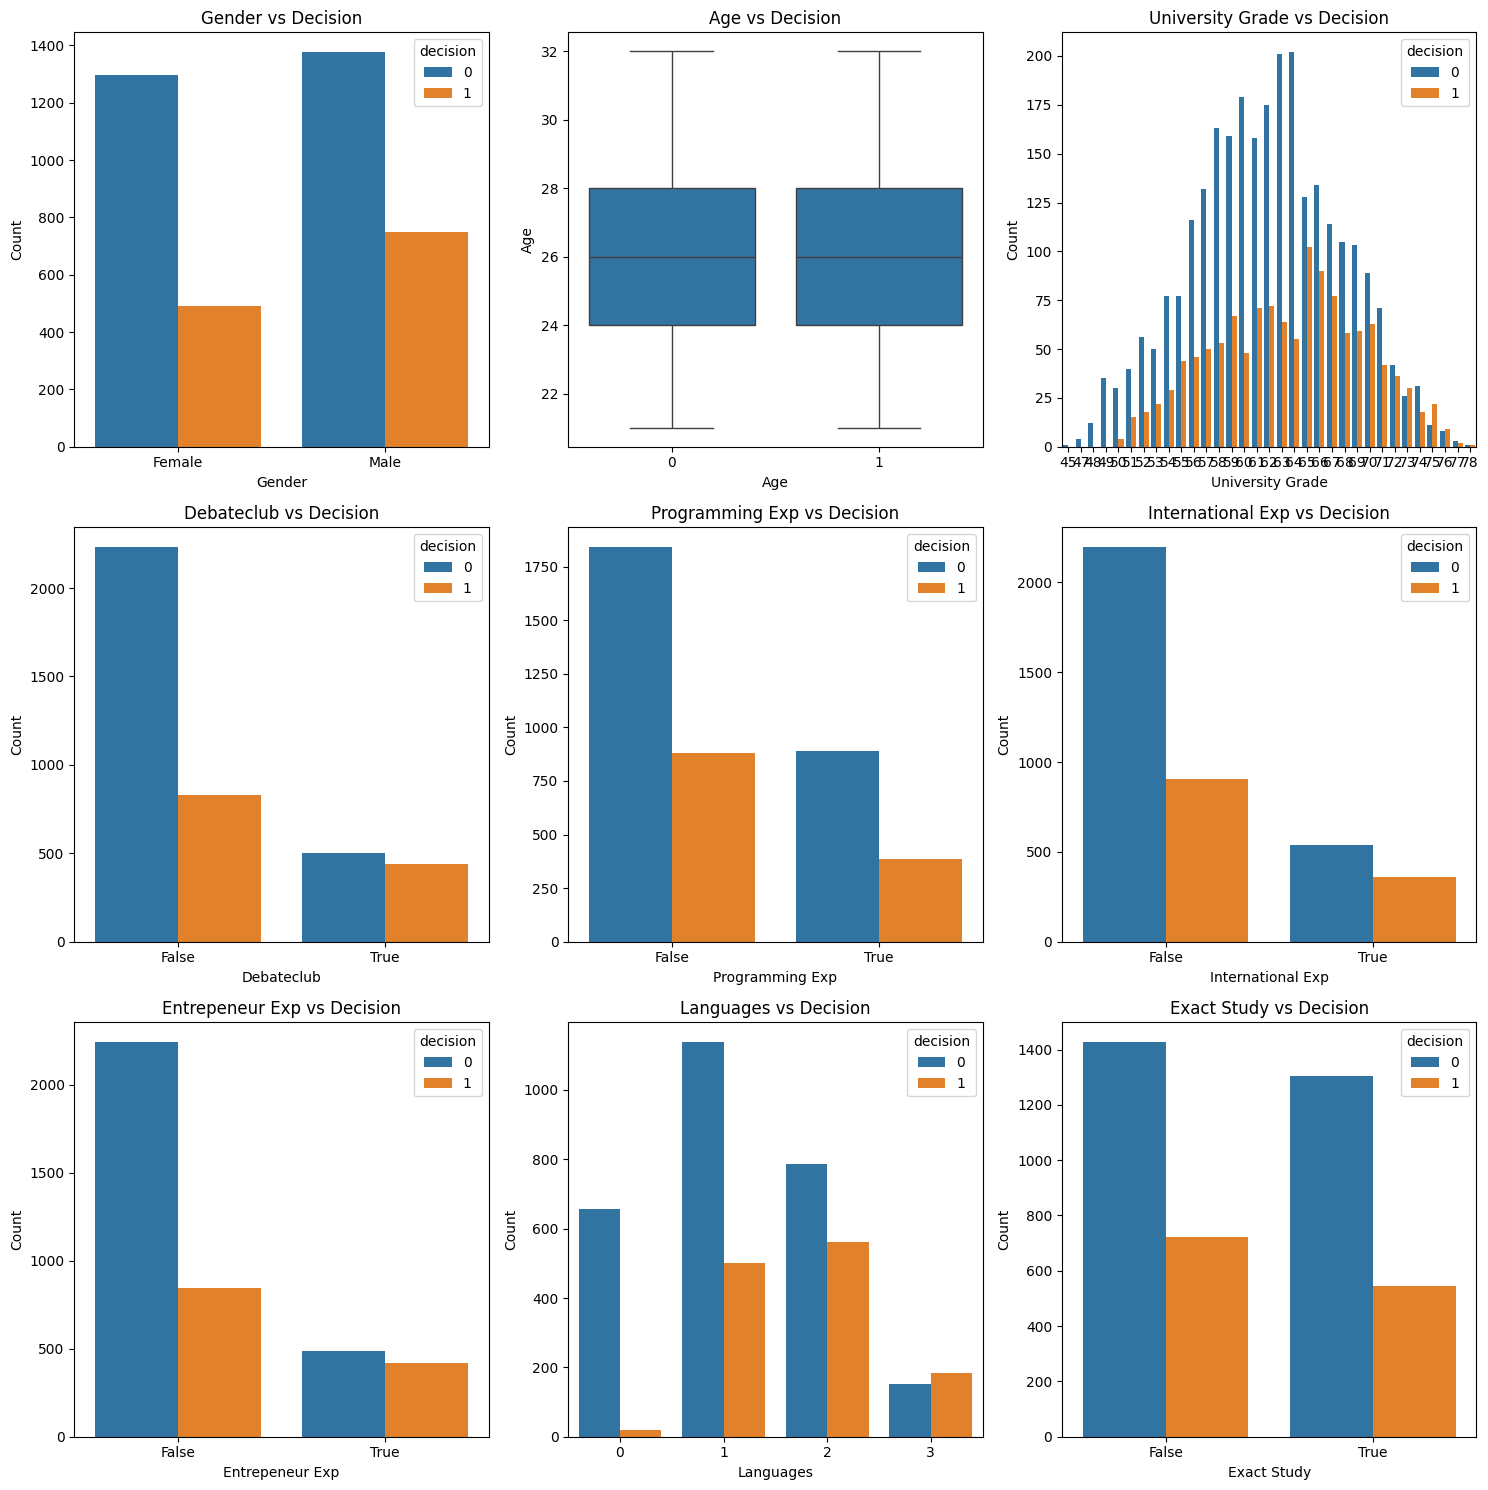

In [53]:
# Initialize the GenderBiasAnalysis class with the dataset
analysis = GenderBiasAnalysis('../data/recruitment_dataset.csv')

# Preprocess the data
analysis.preprocess_data()

# Plot the data to visualize the relationships
analysis.plot_data()


In [54]:
# Perform Chi-Square Test for gender bias
p_value = analysis.chi_square_test()
if p_value < 0.05:
    print("There is significant gender-based bias in the dataset.")
else:
    print("There is no significant gender-based bias in the dataset.")

Chi-Square Test Results: Chi-Square = 26.77640016379292, p-value = 2.2840980419948216e-07
There is significant gender-based bias in the dataset.



### Part 1 : Non-linear Regression

In [55]:
# Run Decision Tree (Non-linear regression) to analyze gender bias
tree_accuracy = analysis.decision_tree()

Decision Tree Accuracy: 0.6975


In the context of our term project, which aims to identify biases in hiring decisions, a decision tree model serves as an important tool for analyzing and predicting patterns in the data. The core objective of our project is to assess whether biases—such as those based on gender, age, education, or employee satisfaction—exist in hiring or resignation decisions. This aligns well with the application of machine learning models like decision trees to gain insights into the impact of these features on the outcome of hiring and resignation decisions.

### Decision Tree as a Non-Linear Model

The decision tree classifier used in our project is a non-linear model that breaks down the complex decision-making process into a series of decisions (splits) based on the features in the dataset. These splits are made by evaluating the significance of each feature in relation to the target variable, which in our case, likely corresponds to whether an individual is hired or resigned. Unlike linear regression, which assumes a linear relationship between the input features and the output, decision trees are well-suited for capturing non-linear relationships in the data. This is particularly relevant because human decisions, such as hiring or resignation, are often influenced by multiple interdependent factors that cannot be captured by a simple linear model.

### Accuracy and Model Evaluation

The accuracy score of 0.6975 that you obtained provides an initial benchmark of the model’s performance in predicting the outcomes of hiring and resignation decisions. While 69.75% accuracy may seem moderate, it is important to consider the context and the nature of the data. Biases in hiring decisions are often subtle and may not always be easily detectable. Therefore, the accuracy score should be interpreted not as an absolute measure of model success, but as a starting point for understanding the relationships between the features and outcomes. In a real-world scenario, biases may manifest in small, yet impactful, patterns that a model like a decision tree can help uncover.

### Identifying Biases

A key aspect of our project is to identify if certain factors, such as gender, age, or education level, influence hiring or resignation decisions in a biased manner. The decision tree classifier helps with this by providing feature importance, which shows which attributes most influence the model's predictions. By analyzing which features are selected at each split, you can identify whether certain features, such as gender or age, disproportionately affect hiring or resignation decisions. For example, if the decision tree model consistently splits based on gender, even when other features are also significant, this may indicate potential gender bias in the hiring process. Similarly, features like education level and employee satisfaction could reveal patterns where certain groups of people are more likely to be hired or resign, suggesting underlying biases.

### Model Limitations and Further Analysis

While the decision tree provides valuable insights, it also comes with limitations. Decision trees are prone to overfitting, especially if they are not pruned properly. Overfitting can lead to a model that performs well on training data but generalizes poorly to new, unseen data. Additionally, decision trees do not inherently provide an understanding of the causal relationships between features and outcomes, only correlations. Therefore, it is essential to complement the decision tree analysis with other models or techniques, such as feature importance analysis, permutation testing, or fairness testing, to ensure that any identified biases are genuinely reflective of the hiring process rather than artifacts of the model.

### Conclusion

In conclusion, the decision tree classifier is a useful tool for our term project, as it allows for the exploration of non-linear relationships between hiring decisions and various features in the dataset. The model's accuracy of 0.6975 provides an initial understanding of the prediction performance, but further analysis is needed to validate whether biases exist and are being detected accurately. By examining feature importance and assessing the fairness of the model’s predictions, you can draw more meaningful conclusions about potential biases in hiring and resignation decisions.

### Part 2 : Logistic Regression

In [56]:
# Run Logistic Regression to analyze gender bias
logistic_accuracy = analysis.logistic_regression()

Logistic Regression Accuracy: 0.73875
Logistic Regression Confusion Matrix:
[[512  55]
 [154  79]]


Logistic regression is a widely used model in predictive analytics and serves as a powerful tool for analyzing relationships between a binary outcome variable and one or more predictor variables. In the context of our term project, which seeks to explore and identify biases in hiring and resignation decisions, logistic regression offers a way to understand the impact of different features—such as gender—on these outcomes.

### Logistic Regression in the Context of Bias Analysis

Logistic regression is particularly well-suited for problems where the dependent variable is binary. In our case, this would involve predicting a binary outcome such as whether an individual is hired or resigned. By fitting a logistic regression model, you can estimate the probability of an individual being hired (or resigning) based on various factors, including age, gender, education level, employee satisfaction, and others. The model uses a logistic function to model the probability of an event occurring, which provides insight into how each feature influences the likelihood of a particular outcome.

### Relevance to Gender Bias

Gender bias is a specific concern in many industries, and our project aims to uncover any patterns or biases that may exist in hiring or resignation decisions based on gender. Logistic regression helps to assess the relationship between gender (as one of the independent variables) and hiring or resignation outcomes (the dependent variable). By including gender as a predictor, you can evaluate whether it significantly affects the model’s predictions. If the logistic regression model finds a high coefficient for gender, especially if it suggests that being of a particular gender increases the likelihood of being hired or resigned, this could indicate a potential bias in the hiring or resignation decisions made by companies.

The logistic regression model can also provide useful metrics to assess gender bias, such as the odds ratio. The odds ratio tells you how much more likely an individual is to be hired or resigned based on their gender. For instance, an odds ratio significantly different from 1 would indicate that gender plays a significant role in the hiring process. If the model suggests that one gender is favored over another, it would signal a possible gender bias in the data, which aligns with the objective of our project to investigate such biases.

### Accuracy and Model Evaluation

The accuracy of the logistic regression model serves as an indicator of how well the model predicts hiring or resignation decisions based on the features in the dataset. This metric provides an overall evaluation of the model’s performance, but it is important to consider other evaluation metrics, such as precision, recall, and F1-score, especially when dealing with imbalanced classes. In the context of gender bias, it is crucial to evaluate whether the model is appropriately distinguishing between outcomes based on gender, without being swayed by other features like age or education. If the logistic regression model achieves a high accuracy while still highlighting gender as a significant predictor, it reinforces the hypothesis that gender bias may be a factor in the hiring or resignation process.

### Limitations of Logistic Regression

While logistic regression is a valuable tool for analyzing binary outcomes, it does have limitations. One such limitation is its assumption of linearity between the independent variables and the log-odds of the dependent variable. In the case of complex hiring decisions, there may be non-linear relationships between features like gender, education, or satisfaction, which logistic regression may not fully capture. Additionally, logistic regression is sensitive to multicollinearity, which could arise if multiple predictors are highly correlated with one another. If gender is correlated with other features such as education level or age, the logistic regression model may not be able to isolate the effect of gender on hiring or resignation decisions.

### Conclusion

Logistic regression is an important model for our term project as it helps to identify and assess the impact of gender on hiring and resignation decisions, a critical area of focus in analyzing biases in the workplace. By providing insights into how gender influences the probability of being hired or resigned, logistic regression contributes to understanding whether biases exist in the decision-making process. While the model offers valuable predictions, it is essential to consider its limitations and complement it with other techniques to ensure a comprehensive analysis of the potential biases present in the data. Ultimately, logistic regression serves as a foundational tool in uncovering gender biases in hiring decisions and contributes to the overall goal of identifying and mitigating such biases in organizational processes.